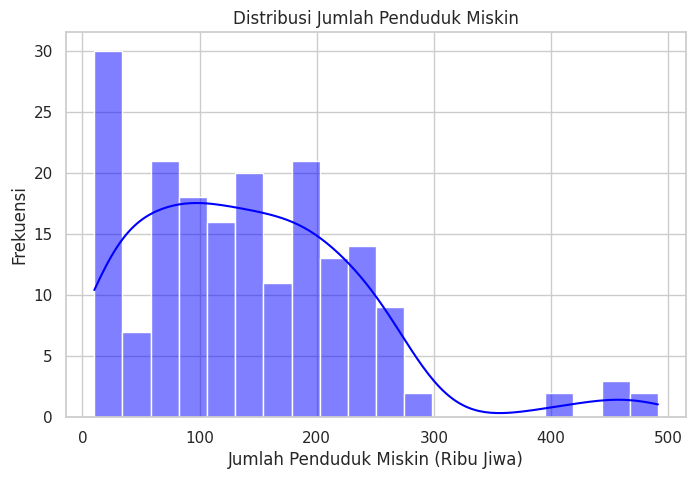

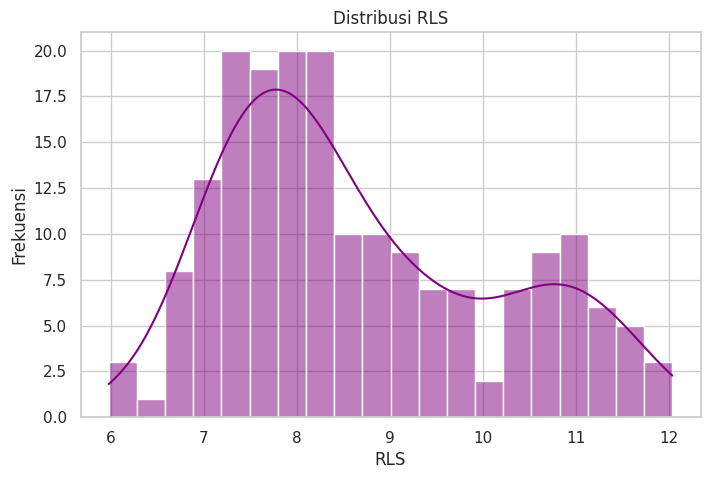

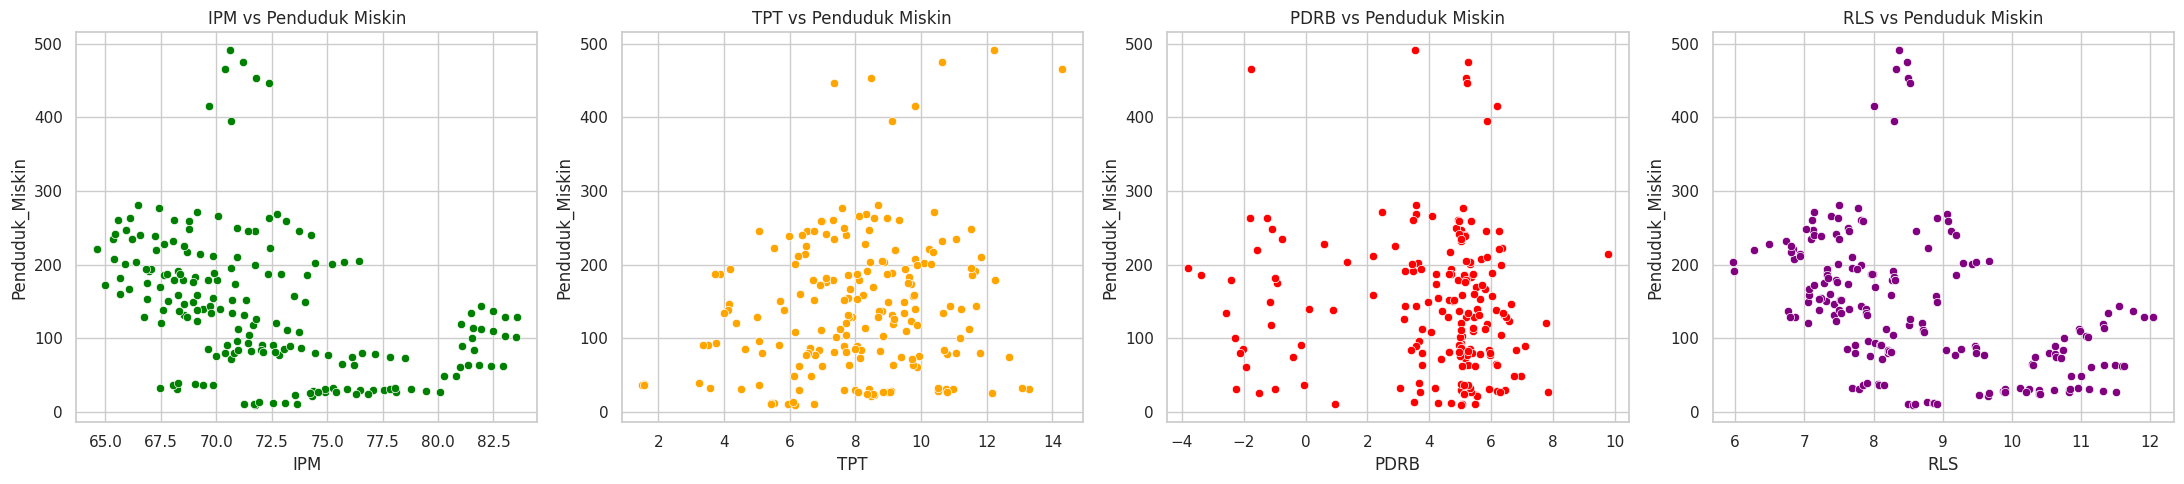

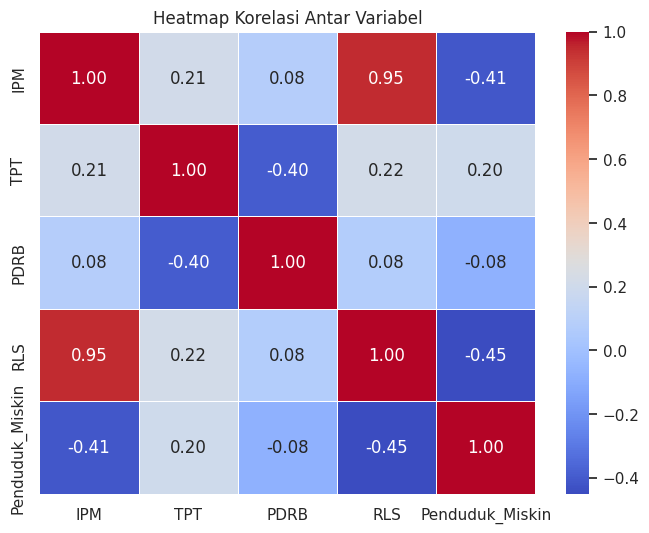

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("dataset.csv")

# Set style
sns.set_theme(style="whitegrid")

# ========================
# 1. Distribusi target
# ========================
plt.figure(figsize=(8, 5))
sns.histplot(df['Penduduk_Miskin'], kde=True, color='blue', bins=20)
plt.title('Distribusi Jumlah Penduduk Miskin')
plt.xlabel('Jumlah Penduduk Miskin (Ribu Jiwa)')
plt.ylabel('Frekuensi')
plt.show()

# ========================
# 2. Distribusi RLS (fitur baru)
# ========================
plt.figure(figsize=(8, 5))
sns.histplot(df['RLS'], kde=True, color='purple', bins=20)
plt.title('Distribusi RLS')
plt.xlabel('RLS')
plt.ylabel('Frekuensi')
plt.show()

# ========================
# 3. Scatter plot hubungan fitur dengan target
# ========================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

sns.scatterplot(data=df, x='IPM', y='Penduduk_Miskin', ax=axes[0], color='green')
axes[0].set_title('IPM vs Penduduk Miskin')

sns.scatterplot(data=df, x='TPT', y='Penduduk_Miskin', ax=axes[1], color='orange')
axes[1].set_title('TPT vs Penduduk Miskin')

sns.scatterplot(data=df, x='PDRB', y='Penduduk_Miskin', ax=axes[2], color='red')
axes[2].set_title('PDRB vs Penduduk Miskin')

sns.scatterplot(data=df, x='RLS', y='Penduduk_Miskin', ax=axes[3], color='purple')
axes[3].set_title('RLS vs Penduduk Miskin')

plt.tight_layout()
plt.show()

# ========================
# 4. Heatmap korelasi (eksplisit)
# ========================
plt.figure(figsize=(8, 6))
corr = df[['IPM','TPT','PDRB','RLS','Penduduk_Miskin']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()


In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ========================
# PERSIAPAN DATA
# ========================
X = pd.get_dummies(df.drop(columns=['Penduduk_Miskin']), columns=['Wilayah'], drop_first=True)

# Log Transform Target
y = np.log1p(df['Penduduk_Miskin'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ========================
# TRAINING MODEL
# ========================
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_percentage_error',
    verbose=1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# ========================
# PREDIKSI + KEMBALIKAN KE ANGKA NORMAL
# ========================
y_pred_log = best_rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_asli = np.expm1(y_test)

# ========================
# EVALUASI
# ========================
mae = mean_absolute_error(y_test_asli, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_asli, y_pred))
mape = np.mean(np.abs((y_test_asli - y_pred) / y_test_asli)) * 100
r2 = r2_score(y_test_asli, y_pred)

print("--- HASIL EVALUASI MODEL ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2 Score : {r2:.4f}")

# ========================
# FITUR PALING BERPENGARUH (TANPA WILAYAH)
# ========================
importances = best_rf.feature_importances_
feature_names = X.columns

# Kita HANYA memasukkan indikator makro ke dalam wadah
importance_dict = {
    'IPM': 0,
    'TPT': 0,
    'PDRB': 0,
    'RLS': 0,
    'Tahun': 0
}

# Menyaring bobot
for name, imp in zip(feature_names, importances):
    if name in importance_dict:
        importance_dict[name] += imp

# Ubah jadi tabel biar rapi
imp_df = pd.DataFrame(list(importance_dict.items()), columns=['Fitur', 'Tingkat_Pengaruh'])
imp_df = imp_df.sort_values(by='Tingkat_Pengaruh', ascending=False).reset_index(drop=True)

print("\n--- FITUR MAKRO PALING BERPENGARUH ---")
print(imp_df)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
--- HASIL EVALUASI MODEL ---
MAE  : 29.95
RMSE : 41.08
MAPE : 24.65%
R2 Score : 0.8161

--- FITUR MAKRO PALING BERPENGARUH ---
   Fitur  Tingkat_Pengaruh
0    RLS          0.199317
1    IPM          0.174588
2    TPT          0.084762
3   PDRB          0.055735
4  Tahun          0.023525


--- 10 KONDISI KEMISKINAN TERTINGGI ---
    Wilayah  Tahun  Penduduk_Miskin  Prediksi_Miskin Status_Kemiskinan
25    Bogor   2022            474.7       409.469268            Tinggi
26    Bogor   2023            453.8       399.985277            Tinggi
23    Bogor   2020            465.7       395.737736            Tinggi
27    Bogor   2024            446.8       383.471671            Tinggi
24    Bogor   2021            491.2       370.216334            Tinggi
22    Bogor   2019            395.0       365.872574            Tinggi
21    Bogor   2018            415.0       364.225076            Tinggi
52    Garut   2021            281.4       256.178748            Sedang
38  Cianjur   2021            260.0       245.419494            Sedang
39  Cianjur   2022            246.8       241.294742            Sedang


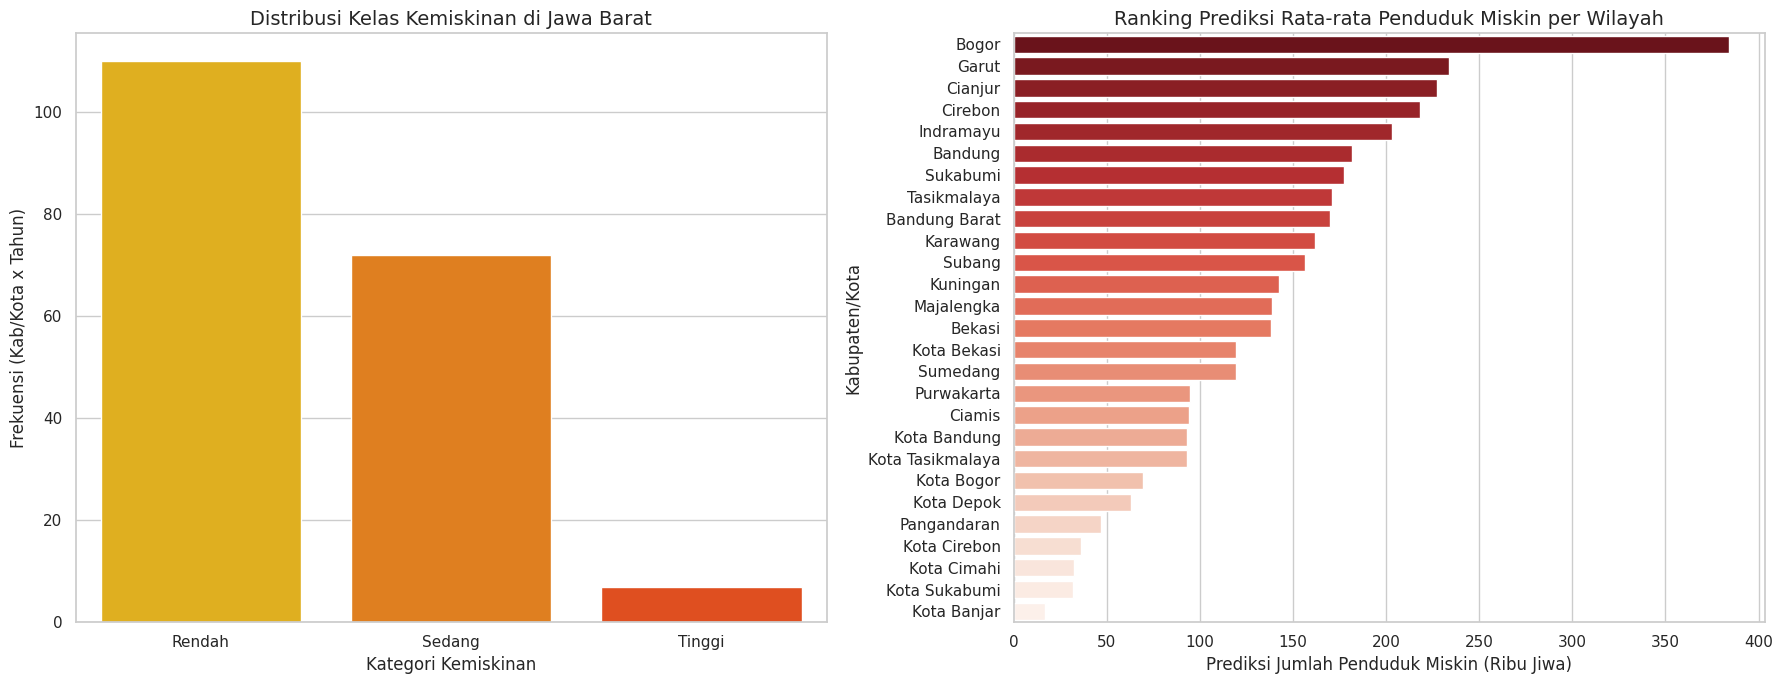

In [10]:
# ========================
# PREDIKSI KE SELURUH DATA
# ========================
pred_log = best_rf.predict(X)

# BALIK KE NILAI ASLI
df['Prediksi_Miskin'] = np.expm1(pred_log)

df['Status_Kemiskinan'] = pd.cut(
    df['Prediksi_Miskin'],
    bins=3,
    labels=['Rendah', 'Sedang', 'Tinggi']
)

df_hasil = df.sort_values(by='Prediksi_Miskin', ascending=False)

print("--- 10 KONDISI KEMISKINAN TERTINGGI ---")
print(df_hasil[['Wilayah', 'Tahun', 'Penduduk_Miskin', 'Prediksi_Miskin', 'Status_Kemiskinan']].head(10))

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(
    data=df_hasil,
    x='Status_Kemiskinan',
    palette='autumn_r',
    order=['Rendah', 'Sedang', 'Tinggi'],
    ax=axes[0],
    hue='Status_Kemiskinan',
    legend=False
)
axes[0].set_title('Distribusi Kelas Kemiskinan di Jawa Barat', fontsize=14)
axes[0].set_xlabel('Kategori Kemiskinan')
axes[0].set_ylabel('Frekuensi (Kab/Kota x Tahun)')

rata_rata_wilayah = df_hasil.groupby('Wilayah')['Prediksi_Miskin'] \
    .mean().sort_values(ascending=False).reset_index()

sns.barplot(
    data=rata_rata_wilayah,
    x='Prediksi_Miskin',
    y='Wilayah',
    palette='Reds_r',
    ax=axes[1],
    hue='Wilayah',
    legend=False
)
axes[1].set_title('Ranking Prediksi Rata-rata Penduduk Miskin per Wilayah', fontsize=14)
axes[1].set_xlabel('Prediksi Jumlah Penduduk Miskin (Ribu Jiwa)')
axes[1].set_ylabel('Kabupaten/Kota')

plt.tight_layout()
plt.show()

In [ ]:
# ========================
# EXPORT MODEL, KOLOM, DAN BINS
# ========================
import joblib
import sklearn

# 1. Export model terbaik
joblib.dump(best_rf, "model_rfr.pkl")
print("Model berhasil disimpan ke model_rfr.pkl")

# 2. Export daftar kolom training (WAJIB untuk reindex di app.py)
joblib.dump(list(X.columns), "model_columns.pkl")
print(f"Kolom training ({len(X.columns)} kolom) berhasil disimpan ke model_columns.pkl")
print("Daftar kolom:")
for col in X.columns:
    print(f"  - {col}")

# 3. Cetak threshold bins dari pd.cut untuk di-hardcode di app.py
_, bins = pd.cut(df["Prediksi_Miskin"], bins=3, labels=["Rendah", "Sedang", "Tinggi"], retbins=True)
print(f"\nThreshold bins untuk klasifikasi: {list(bins)}")
print(f"  Rendah : <= {bins[1]:.2f} ribu jiwa")
print(f"  Sedang : {bins[1]:.2f} - {bins[2]:.2f} ribu jiwa")
print(f"  Tinggi : > {bins[2]:.2f} ribu jiwa")

# 4. Cek versi scikit-learn (WAJIB dicatat untuk requirements.txt)
print(f"\nscikit-learn version: {sklearn.__version__}")
print("PENTING: Catat versi di atas dan masukkan ke requirements.txt!")
